In [53]:
# ==============================================================================
# JUPYTER NOTEBOOK: SIMULATION OF TRAFFIC & DEMAND FLUCTUATIONS
# ==============================================================================

import io
import math
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from pandas import read_csv


In [54]:
# ------------------------------------------------------------------------------
# 1. SETUP & CONSTANTS
# ------------------------------------------------------------------------------
N_SIMULATIONS = 1000
RANDOM_SEED = 263
rng = np.random.default_rng(RANDOM_SEED)

# Financial & Operational Parameters
UNLOAD_MINUTES_PER_PALLET = 18.0
TRUCK_COST_PER_HOUR = 220.0
OVERTIME_THRESHOLD_HOURS = 4.0
OVERTIME_COST_PER_HOUR = 310.0
WET_LEASE_COST_PER_2H_BLOCK = 1400.0
TRUCK_CAPACITY = 16.0  # Max pallets per truck
CONFLICT_GRACE_PERIOD_MINUTES = 0  # Buffer between AM and PM shifts

# Variability Parameters
SHIFT_TO_SHIFT_SIGMA = 0.10  # Log-normal shift-level traffic std dev
ROUTE_TO_ROUTE_SIGMA = 0.06  # Log-normal route-level traffic std dev
DEMAND_SIGMA_FRACTION = 0.15  # Normal distribution std dev for demand

# Mean traffic multiplier per shift
SHIFT_TRAFFIC_MEAN = {
    "8am": 1.03,
    "2pm": 1.02,
}

# Set plot style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)


In [55]:
# ------------------------------------------------------------------------------
# 2. LOAD DATA
# ------------------------------------------------------------------------------
# Read directly from the file path
routes_df = pd.read_csv("project_data/Optimal_Routes.csv")
routes_df.rename(columns={"Pallets": "Demand"}, inplace=True)

# Assign routes to Shifts (8am for first half, 2pm for second half per day-type)
routes_df["Scheduled_Shift"] = "8am"
for day_label, group_idx in routes_df.groupby("Day").groups.items():
    half = len(group_idx) // 2
    routes_df.loc[group_idx.values[half:], "Scheduled_Shift"] = "2pm"

# Pair up trucks across shifts (assigning 1 to 20 per shift)
for shift_name, group_idx in routes_df.groupby("Scheduled_Shift").groups.items():
    for i, idx in enumerate(group_idx):
        routes_df.loc[idx, "Truck"] = f"Truck_{i + 1}"

In [56]:

# ------------------------------------------------------------------------------
# 3. HELPER FUNCTIONS
# ------------------------------------------------------------------------------
def calculate_route_cost(hours: float) -> float:
    """Calculates cost for a route including overtime rates."""
    if hours <= OVERTIME_THRESHOLD_HOURS:
        return hours * TRUCK_COST_PER_HOUR
    normal_part = OVERTIME_THRESHOLD_HOURS * TRUCK_COST_PER_HOUR
    overtime_hours = math.ceil(hours - OVERTIME_THRESHOLD_HOURS - 1e-12)
    return normal_part + overtime_hours * OVERTIME_COST_PER_HOUR

def run_simulation(group: pd.DataFrame, n_simulations: int, rng: np.random.Generator) -> pd.DataFrame:
    """Simulates random demand (a) and traffic (b) variations 1000 times."""
    group = group.reset_index(drop=True)
    baseline_pallets = group["Demand"].to_numpy(dtype=float)
    baseline_unload_hours = baseline_pallets * UNLOAD_MINUTES_PER_PALLET / 60.0
    baseline_drive_hours = np.maximum(0.0, group["Duration_hours"].to_numpy() - baseline_unload_hours)
    shifts = group["Scheduled_Shift"].to_numpy()
    trucks = group["Truck"].to_numpy()
    n_routes = len(group)

    # Track double-booked trucks across shifts
    truck_shift_rows = {}
    for i, (truck, shift) in enumerate(zip(trucks, shifts)):
        truck_shift_rows.setdefault(truck, {})[shift] = i
    double_shift_trucks = {
        truck: rows for truck, rows in truck_shift_rows.items()
        if "8am" in rows and "2pm" in rows
    }
    shift_start_hour = {"8am": 8.0, "2pm": 14.0}

    results = []
    for sim in range(1, n_simulations + 1):
        # 1. Demand variation (a)
        demand_sim = rng.normal(baseline_pallets, baseline_pallets * DEMAND_SIGMA_FRACTION)
        demand_sim = np.clip(np.round(demand_sim), 0, None)

        capped_demand = np.minimum(demand_sim, TRUCK_CAPACITY)
        overflow_demand = np.maximum(0.0, demand_sim - TRUCK_CAPACITY)
        unload_hours_sim = capped_demand * UNLOAD_MINUTES_PER_PALLET / 60.0

        # 2. Traffic variation (b)
        traffic_factor = np.empty(n_routes)
        for shift_name, mean_mult in SHIFT_TRAFFIC_MEAN.items():
            mask = shifts == shift_name
            if not mask.any():
                continue
            shift_draw = rng.lognormal(mean=math.log(mean_mult) - 0.5 * SHIFT_TO_SHIFT_SIGMA ** 2, sigma=SHIFT_TO_SHIFT_SIGMA)
            route_draws = rng.lognormal(mean=-0.5 * ROUTE_TO_ROUTE_SIGMA ** 2, sigma=ROUTE_TO_ROUTE_SIGMA, size=mask.sum())
            traffic_factor[mask] = shift_draw * route_draws

        # 3. Calculate actual time
        actual_hours = baseline_drive_hours * traffic_factor + unload_hours_sim

        # 4. Standard route costs
        costs = np.array([calculate_route_cost(h) for h in actual_hours])

        # 5. Wet lease costs from demand overflows
        overflow_cost = 0.0
        n_overflow_events = int((overflow_demand > 0).sum())
        if n_overflow_events > 0:
            overflow_hours = baseline_drive_hours + overflow_demand * UNLOAD_MINUTES_PER_PALLET / 60.0
            overflow_hours = overflow_hours[overflow_demand > 0]
            overflow_blocks = np.ceil(overflow_hours / 2.0 - 1e-12)
            overflow_cost = float((overflow_blocks * WET_LEASE_COST_PER_2H_BLOCK).sum())

        # 6. Wet lease costs from traffic schedule conflicts (AM overrun into PM slot)
        wet_lease_cost = 0.0
        n_conflicts = 0
        for truck, rows_by_shift in double_shift_trucks.items():
            am_idx, pm_idx = rows_by_shift["8am"], rows_by_shift["2pm"]
            am_finish_clock = shift_start_hour["8am"] + actual_hours[am_idx]
            grace_hours = CONFLICT_GRACE_PERIOD_MINUTES / 60.0
            if am_finish_clock > shift_start_hour["2pm"] + grace_hours:
                n_conflicts += 1
                costs[pm_idx] = math.ceil(actual_hours[pm_idx] / 2.0 - 1e-12) * WET_LEASE_COST_PER_2H_BLOCK
                wet_lease_cost += costs[pm_idx]

        total_cost = costs.sum() + overflow_cost

        results.append({
            "simulation": sim,
            "total_hours": actual_hours.sum(),
            "routes_over_4h": int((actual_hours > 4.0).sum()),
            "shift_conflicts": n_conflicts,
            "wet_lease_cost": wet_lease_cost,
            "overflow_events": n_overflow_events,
            "overflow_cost": overflow_cost,
            "total_cost": total_cost,
        })

    return pd.DataFrame(results)


In [57]:
# ------------------------------------------------------------------------------
# 4. EXECUTE MONTE CARLO SIMULATIONS
# ------------------------------------------------------------------------------
all_sim_results = []
for day_label, group in routes_df.groupby("Day"):
    sim_df = run_simulation(group, N_SIMULATIONS, rng)
    sim_df.insert(0, "Day", day_label)
    all_sim_results.append(sim_df)

sim_results_df = pd.concat(all_sim_results, ignore_index=True)


In [58]:

# ------------------------------------------------------------------------------
# 5. SUMMARY METRICS TABLE
# ------------------------------------------------------------------------------
summary_stats = sim_results_df.groupby("Day").agg(
    Mean_Total_Cost=("total_cost", "mean"),
    Median_Total_Cost=("total_cost", "median"),
    P95_Total_Cost=("total_cost", lambda x: x.quantile(0.95)),
    Mean_Truck_Hours=("total_hours", "mean"),
    Shift_Conflict_Probability=("shift_conflicts", lambda x: (x > 0).mean()),
    Demand_Overflow_Probability=("overflow_events", lambda x: (x > 0).mean()),
    Mean_Wet_Lease_Cost=("wet_lease_cost", "mean"),
    Mean_Overflow_Cost=("overflow_cost", "mean"),
).reset_index()

print("=========================================================================")
print("                      SIMULATION RESULTS SUMMARY                         ")
print("=========================================================================")
display(summary_stats.style.format({
    "Mean_Total_Cost": "${:,.2f}",
    "Median_Total_Cost": "${:,.2f}",
    "P95_Total_Cost": "${:,.2f}",
    "Mean_Truck_Hours": "{:,.2f} hrs",
    "Shift_Conflict_Probability": "{:.1%}",
    "Demand_Overflow_Probability": "{:.1%}",
    "Mean_Wet_Lease_Cost": "${:,.2f}",
    "Mean_Overflow_Cost": "${:,.2f}",
}))



                      SIMULATION RESULTS SUMMARY                         


,Day,Mean_Total_Cost,Median_Total_Cost,P95_Total_Cost,Mean_Truck_Hours,Shift_Conflict_Probability,Demand_Overflow_Probability,Mean_Wet_Lease_Cost,Mean_Overflow_Cost
0,Saturday,"$31,028.14","$30,984.34","$36,552.35",103.89 hrs,93.5%,59.2%,"$4,607.40","$1,694.00"
1,Weekdays,"$54,135.14","$53,762.33","$64,646.31",160.30 hrs,94.7%,98.7%,"$8,876.00","$5,905.20"


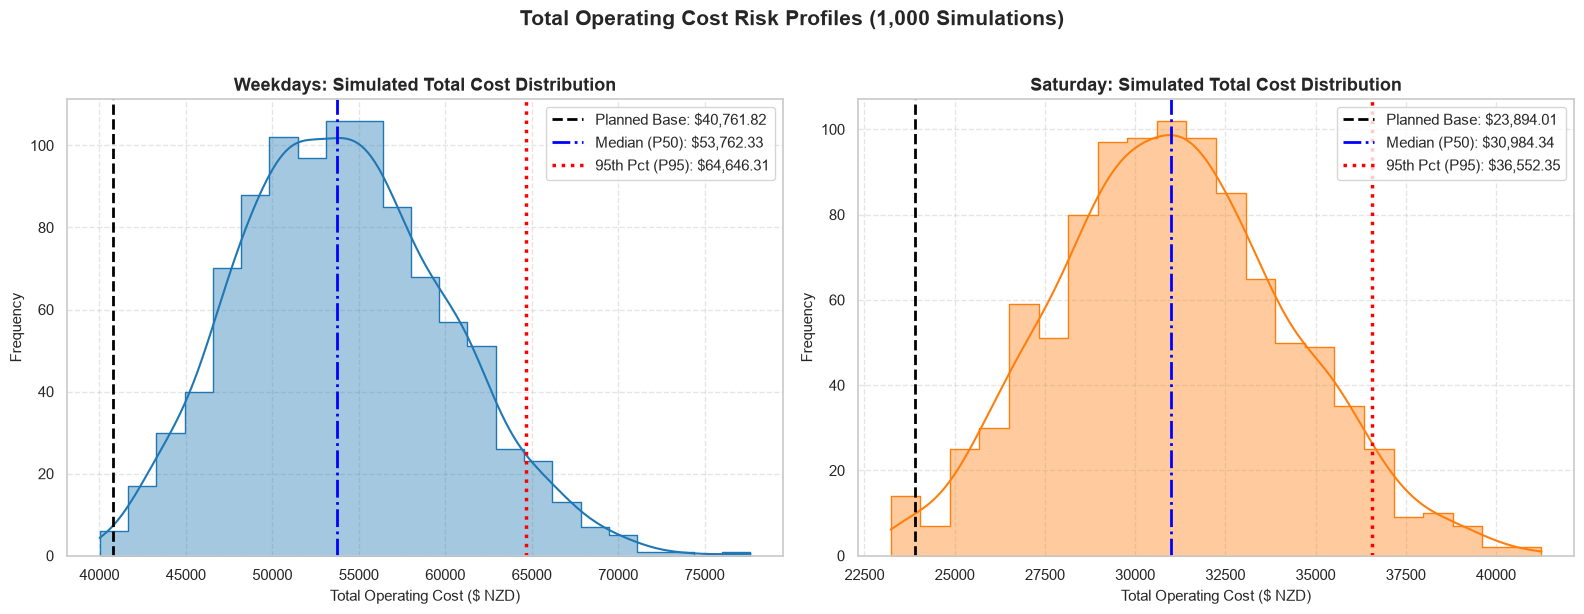

<Figure size 1000x600 with 0 Axes>

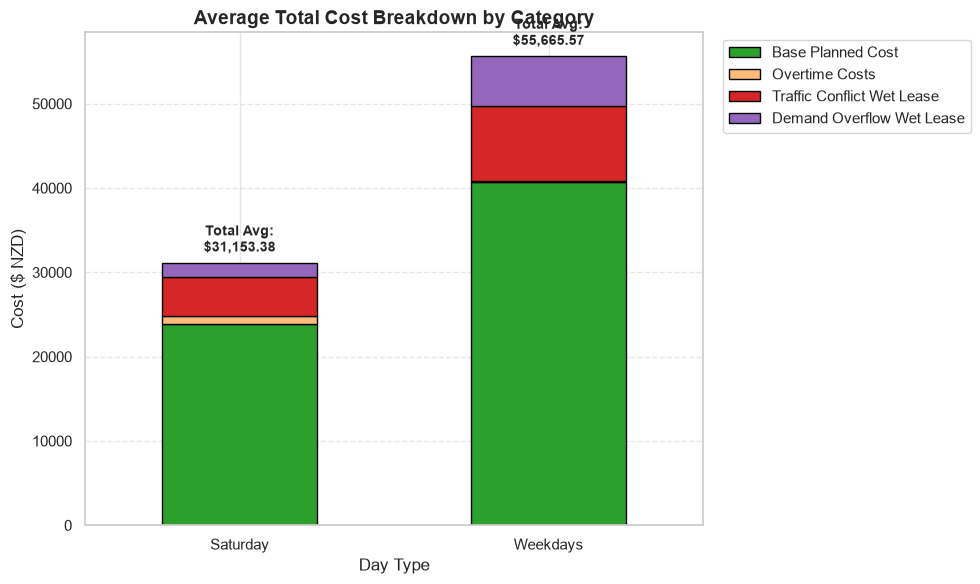

In [59]:
# ------------------------------------------------------------------------------
# 6. PLOTS: TOTAL OPERATING COST ANALYSIS
# ------------------------------------------------------------------------------
# Calculate baseline metrics per Day type from input data
baseline_metrics = routes_df.groupby("Day").agg(
    Original_Cost=("Trip_Cost_NZD", "sum")
).reset_index()

# Compute baseline reference cost per day
sim_results_df["Base_Cost"] = sim_results_df.apply(
    lambda r: baseline_metrics.loc[baseline_metrics["Day"] == r["Day"], "Original_Cost"].values[0],
    axis=1
)

# Compute variable overtime portion (excluding wet leases)
sim_results_df["Overtime_Cost"] = np.maximum(
    0.0,
    sim_results_df["total_cost"] - (sim_results_df["Base_Cost"] + sim_results_df["wet_lease_cost"] + sim_results_df["overflow_cost"])
)

# Extract statistics for distribution benchmarks
sim_stats = sim_results_df.groupby("Day")["total_cost"].agg(
    P50="median",
    P95=lambda x: x.quantile(0.95),
    Mean="mean"
).reset_index()


# ==============================================================================
# FIGURE 1: TOTAL OPERATING COST DISTRIBUTION (WEEKDAYS VS SATURDAY)
# ==============================================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

days = ["Weekdays", "Saturday"]
colors = {"Weekdays": "#1f77b4", "Saturday": "#ff7f0e"}

for i, day in enumerate(days):
    day_sims = sim_results_df[sim_results_df["Day"] == day]
    orig_cost = baseline_metrics.loc[baseline_metrics["Day"] == day, "Original_Cost"].values[0]
    p50_val = sim_stats.loc[sim_stats["Day"] == day, "P50"].values[0]
    p95_val = sim_stats.loc[sim_stats["Day"] == day, "P95"].values[0]

    # Histogram + KDE
    sns.histplot(
        data=day_sims,
        x="total_cost",
        color=colors[day],
        element="step",
        kde=True,
        ax=axes[i],
        alpha=0.4
    )

    # Benchmark Vertical Lines
    axes[i].axvline(orig_cost, color="black", linestyle="--", linewidth=2, label=f"Planned Base: ${orig_cost:,.2f}")
    axes[i].axvline(p50_val, color="blue", linestyle="-.", linewidth=2, label=f"Median (P50): ${p50_val:,.2f}")
    axes[i].axvline(p95_val, color="red", linestyle=":", linewidth=2.5, label=f"95th Pct (P95): ${p95_val:,.2f}")

    axes[i].set_title(f"{day}: Simulated Total Cost Distribution", fontsize=13, fontweight="bold")
    axes[i].set_xlabel("Total Operating Cost ($ NZD)", fontsize=11)
    axes[i].set_ylabel("Frequency", fontsize=11)
    axes[i].legend(loc="upper right")
    axes[i].grid(True, linestyle="--", alpha=0.5)

plt.suptitle("Total Operating Cost Risk Profiles (1,000 Simulations)", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


# ==============================================================================
# FIGURE 2: STANDALONE AVERAGE TOTAL COST BREAKDOWN BY CATEGORY
# ==============================================================================
plt.figure(figsize=(10, 6))

cost_breakdown = sim_results_df.groupby("Day").agg(
    Base_Cost=("Base_Cost", "mean"),
    Overtime_Cost=("Overtime_Cost", "mean"),
    Traffic_Wet_Lease=("wet_lease_cost", "mean"),
    Demand_Overflow=("overflow_cost", "mean")
).reset_index()

# Plot Stacked Bar Chart
ax = cost_breakdown.set_index("Day").plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6),
    color=["#2ca02c", "#ffbb78", "#d62728", "#9467bd"],
    edgecolor="black"
)

plt.title("Average Total Cost Breakdown by Category", fontsize=14, fontweight="bold")
plt.xlabel("Day Type", fontsize=12)
plt.ylabel("Cost ($ NZD)", fontsize=12)
plt.xticks(rotation=0, fontsize=11)
plt.legend(
    ["Base Planned Cost", "Overtime Costs", "Traffic Conflict Wet Lease", "Demand Overflow Wet Lease"],
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    fontsize=11
)
plt.grid(axis="y", linestyle="--", alpha=0.5)

# Annotate total costs and segment values on top of bars
for i, row in cost_breakdown.iterrows():
    total = row["Base_Cost"] + row["Overtime_Cost"] + row["Traffic_Wet_Lease"] + row["Demand_Overflow"]
    ax.annotate(
        f"Total Avg:\n${total:,.2f}",
        (i, total),
        textcoords="offset points",
        xytext=(0, 8),
        ha='center',
        fontweight='bold',
        fontsize=10
    )

plt.tight_layout()
plt.show()

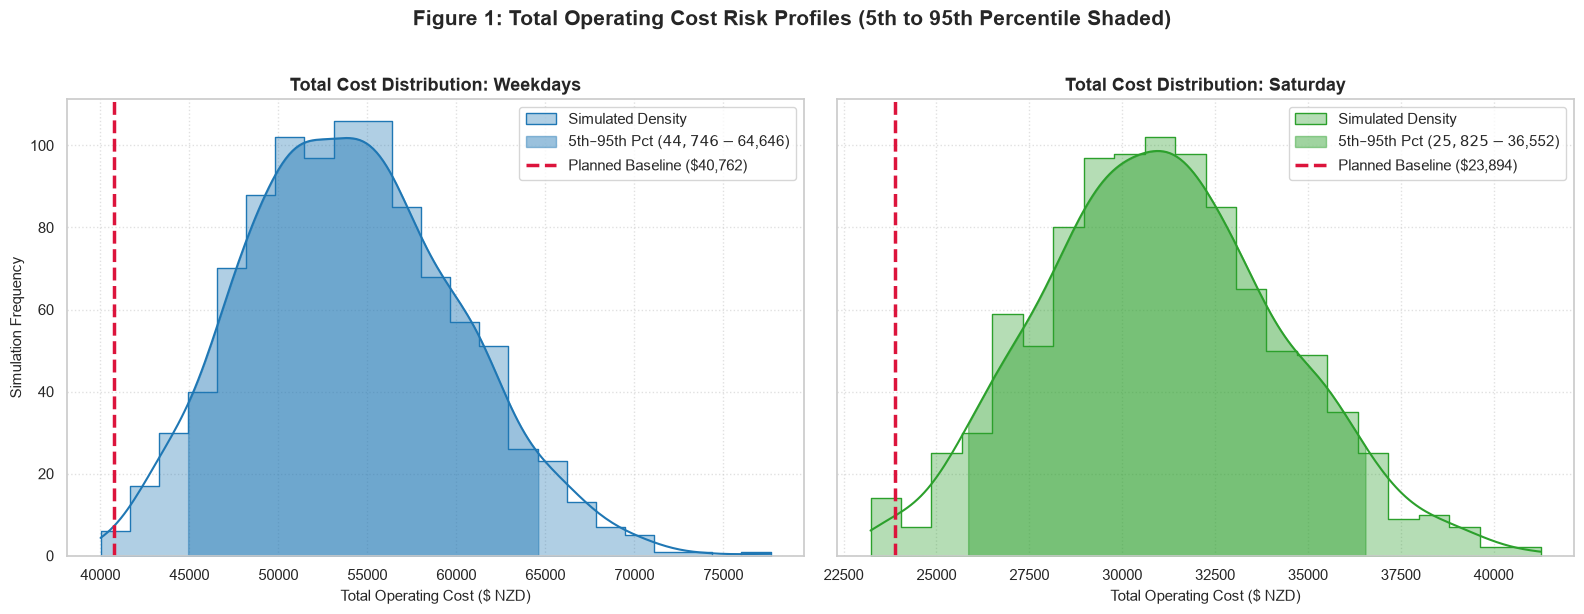

<Figure size 1000x600 with 0 Axes>

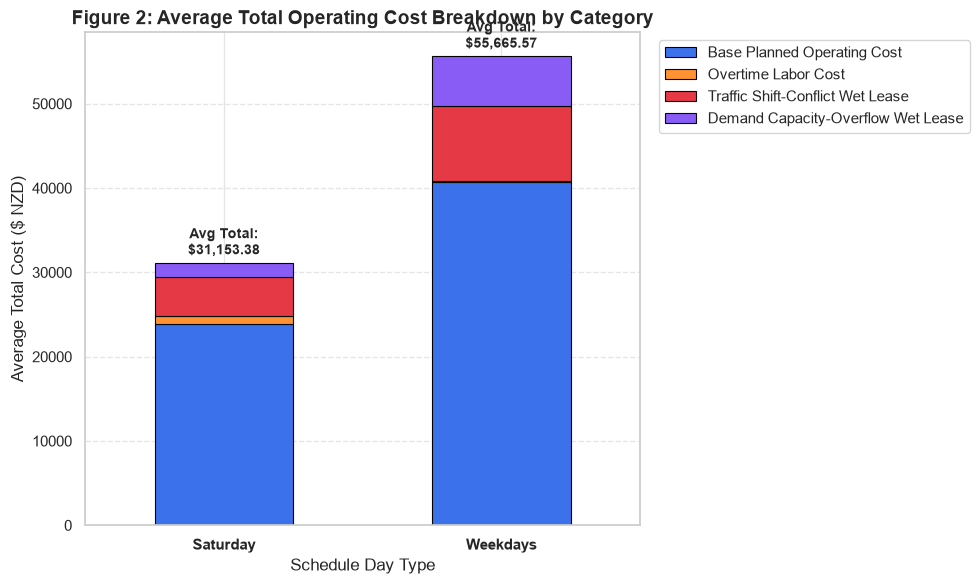

In [60]:
# ------------------------------------------------------------------------------
# 6. PLOTS: TOTAL OPERATING COST ANALYSIS (2 SEPARATE FIGURES)
# ------------------------------------------------------------------------------

# 1. Prepare Baseline & Percentile Statistics
baseline_metrics = routes_df.groupby("Day").agg(
    Original_Cost=("Trip_Cost_NZD", "sum")
).reset_index()

# Set cohesive color palette across both figures
color_map = {
    "Weekdays": "#1f77b4",  # Muted Blue
    "Saturday": "#2ca02c"   # Forest Green
}

# ==============================================================================
# FIGURE 1: TOTAL OPERATING COST (SPLIT BY WEEKDAY AND SATURDAY)
# ==============================================================================
fig1, axes1 = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

days = ["Weekdays", "Saturday"]

for i, day in enumerate(days):
    ax = axes1[i]
    day_sims = sim_results_df[sim_results_df["Day"] == day]["total_cost"]
    orig_cost = baseline_metrics.loc[baseline_metrics["Day"] == day, "Original_Cost"].values[0]

    # Calculate 5th and 95th percentiles
    p5 = day_sims.quantile(0.05)
    p95 = day_sims.quantile(0.95)

    # Histogram plot
    sns.histplot(
        data=day_sims,
        ax=ax,
        color=color_map[day],
        kde=True,
        element="step",
        alpha=0.35,
        label="Simulated Density"
    )

    # Get KDE line data to shade the 5th–95th percentile region
    kde_line = ax.lines[0]
    x_kde = kde_line.get_xdata()
    y_kde = kde_line.get_ydata()

    # Fill 5th to 95th percentile shaded area directly under KDE curve
    ax.fill_between(
        x_kde, 0, y_kde,
        where=(x_kde >= p5) & (x_kde <= p95),
        color=color_map[day],
        alpha=0.45,
        label=f"5th–95th Pct (${p5:,.0f} - ${p95:,.0f})"
    )

    # Original baseline reference line
    ax.axvline(
        orig_cost,
        color="crimson",
        linestyle="--",
        linewidth=2.5,
        label=f"Planned Baseline (${orig_cost:,.0f})"
    )

    ax.set_title(f"Total Cost Distribution: {day}", fontsize=13, fontweight="bold")
    ax.set_xlabel("Total Operating Cost ($ NZD)", fontsize=11)
    if i == 0:
        ax.set_ylabel("Simulation Frequency", fontsize=11)
    ax.legend(loc="upper right", frameon=True)
    ax.grid(True, linestyle=":", alpha=0.6)

plt.suptitle("Figure 1: Total Operating Cost Risk Profiles (5th to 95th Percentile Shaded)", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


# ==============================================================================
# FIGURE 2: STANDALONE AVERAGE TOTAL COST BREAKDOWN BY CATEGORY
# ==============================================================================
plt.figure(figsize=(10, 6))

# Prepare component totals
sim_results_df["Base_Cost"] = sim_results_df.apply(
    lambda r: baseline_metrics.loc[baseline_metrics["Day"] == r["Day"], "Original_Cost"].values[0],
    axis=1
)
sim_results_df["Overtime_Cost"] = np.maximum(0, sim_results_df["total_cost"] - sim_results_df["Base_Cost"] - sim_results_df["wet_lease_cost"] - sim_results_df["overflow_cost"])

cost_breakdown = sim_results_df.groupby("Day").agg(
    Base_Planned_Cost=("Base_Cost", "mean"),
    Overtime_Labor_Cost=("Overtime_Cost", "mean"),
    Traffic_Wet_Lease=("wet_lease_cost", "mean"),
    Demand_Overflow_Wet_Lease=("overflow_cost", "mean")
).reset_index()

# Colors matched to main themes (Base owned cost, Overtime, Traffic Penalty, Demand Overflow)
category_colors = ["#3B72EC", "#FF9233", "#E63946", "#8A5CF6"]

ax2 = cost_breakdown.set_index("Day").plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6),
    color=category_colors,
    edgecolor="black",
    linewidth=0.8
)

plt.title("Figure 2: Average Total Operating Cost Breakdown by Category", fontsize=14, fontweight="bold")
plt.xlabel("Schedule Day Type", fontsize=12)
plt.ylabel("Average Total Cost ($ NZD)", fontsize=12)
plt.xticks(rotation=0, fontsize=11, fontweight="bold")
plt.grid(axis="y", linestyle="--", alpha=0.5)

# Overlay dollar labels on top of stacked bars
for i, row in cost_breakdown.iterrows():
    total = row["Base_Planned_Cost"] + row["Overtime_Labor_Cost"] + row["Traffic_Wet_Lease"] + row["Demand_Overflow_Wet_Lease"]
    ax2.annotate(
        f"Avg Total:\n${total:,.2f}",
        (i, total),
        textcoords="offset points",
        xytext=(0, 6),
        ha='center',
        fontweight='bold',
        fontsize=10
    )

plt.legend(
    labels=[
        "Base Planned Operating Cost",
        "Overtime Labor Cost",
        "Traffic Shift-Conflict Wet Lease",
        "Demand Capacity-Overflow Wet Lease"
    ],
    bbox_to_anchor=(1.02, 1),
    loc='upper left',
    frameon=True
)

plt.tight_layout()
plt.show()

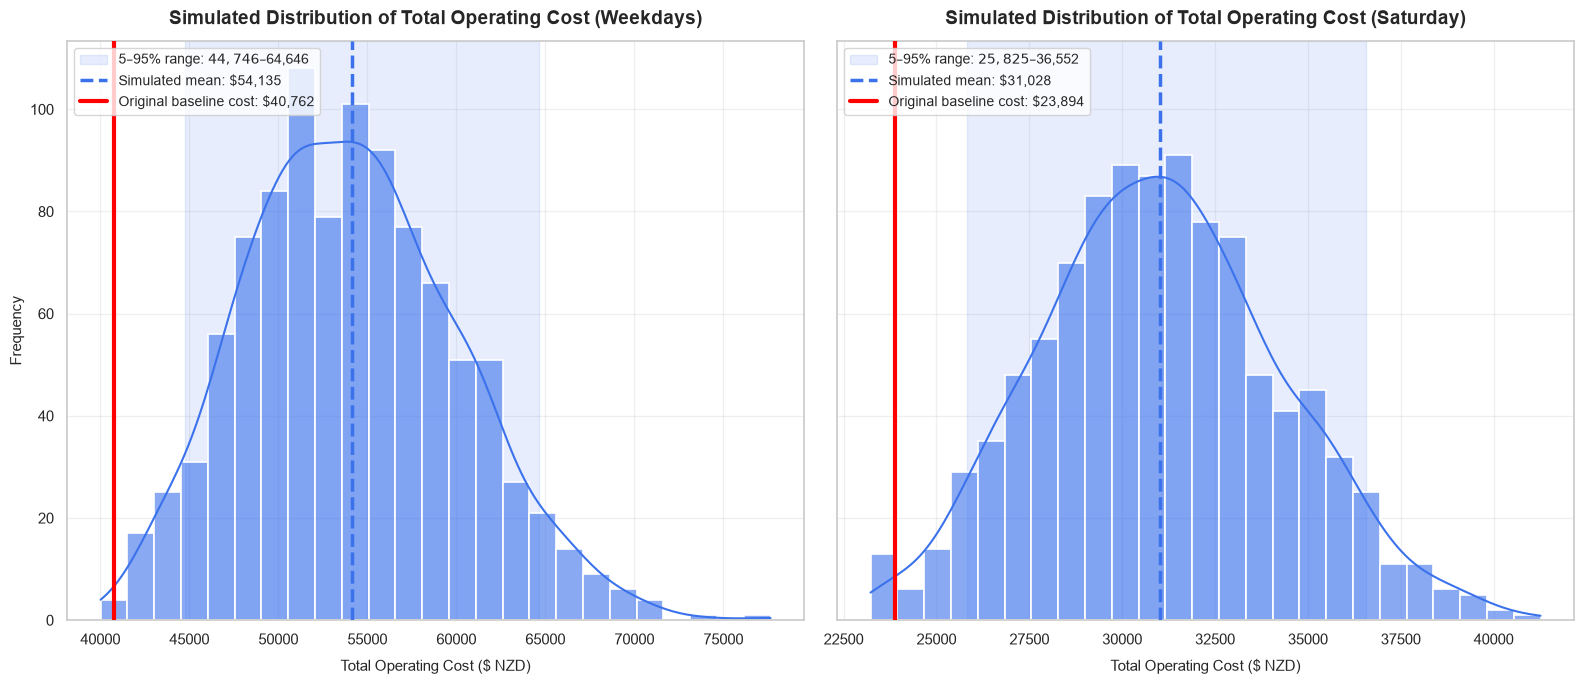

<Figure size 1000x600 with 0 Axes>

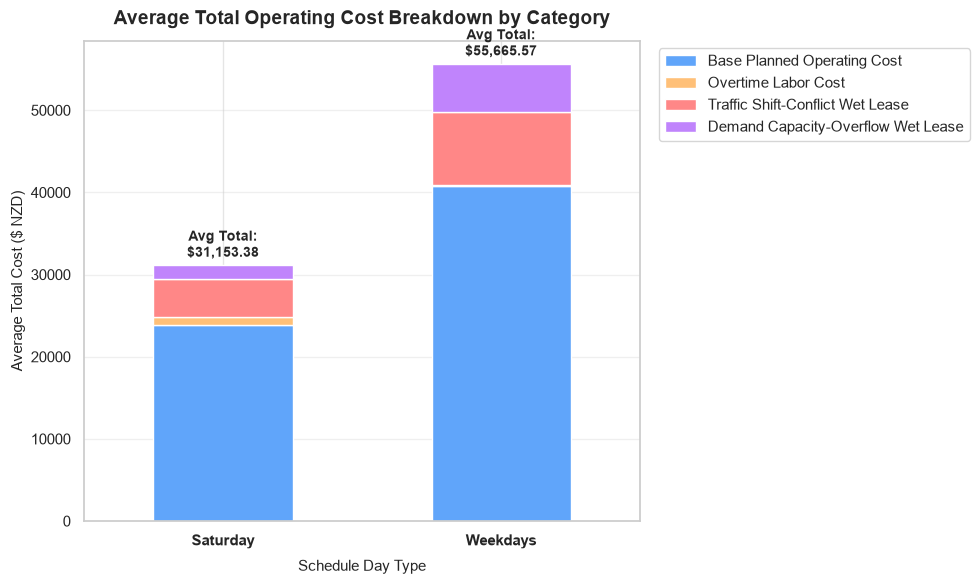

In [61]:
# ------------------------------------------------------------------------------
# 6. PLOTS: TOTAL OPERATING COST ANALYSIS (MATCHING REFERENCE DESIGN)
# ------------------------------------------------------------------------------

# 1. Prepare Baseline & Statistics
baseline_metrics = routes_df.groupby("Day").agg(
    Original_Cost=("Trip_Cost_NZD", "sum")
).reset_index()

sns.set_theme(style="whitegrid")

# ==============================================================================
# FIGURE 1: TOTAL OPERATING COST (SPLIT BY WEEKDAY AND SATURDAY)
# ==============================================================================
fig1, axes1 = plt.subplots(1, 2, figsize=(16, 7), sharey=True)

days = ["Weekdays", "Saturday"]

for i, day in enumerate(days):
    ax = axes1[i]
    day_sims = sim_results_df[sim_results_df["Day"] == day]["total_cost"]
    orig_cost = baseline_metrics.loc[baseline_metrics["Day"] == day, "Original_Cost"].values[0]

    sim_mean = day_sims.mean()
    p5 = day_sims.quantile(0.05)
    p95 = day_sims.quantile(0.95)

    # 1. Full-height background shading for 5–95% range (axvspan)
    ax.axvspan(
        p5, p95,
        color="#3b72ec",
        alpha=0.12,
        zorder=1,
        label=f"5–95% range: ${p5:,.0f}–${p95:,.0f}"
    )

    # 2. Histogram with KDE (matching blue tones and styling)
    sns.histplot(
        data=day_sims,
        ax=ax,
        color="#3b72ec",
        kde=True,
        bins=25,
        edgecolor="white",
        linewidth=1.2,
        alpha=0.6,
        zorder=2
    )

    # 3. Dashed line for Simulation Mean
    ax.axvline(
        sim_mean,
        color="#3b72ec",
        linestyle="--",
        linewidth=2.5,
        zorder=3,
        label=f"Simulated mean: ${sim_mean:,.0f}"
    )

    # 4. Solid red line for Original Baseline Cost
    ax.axvline(
        orig_cost,
        color="red",
        linestyle="-",
        linewidth=3.0,
        zorder=4,
        label=f"Original baseline cost: ${orig_cost:,.0f}"
    )

    # Formatting
    ax.set_title(f"Simulated Distribution of Total Operating Cost ({day})", fontsize=14, fontweight="bold", pad=12)
    ax.set_xlabel("Total Operating Cost ($ NZD)", fontsize=11, labelpad=8)
    if i == 0:
        ax.set_ylabel("Frequency", fontsize=11)

    ax.legend(loc="upper left", frameon=True, facecolor="white", edgecolor="#cccccc", fontsize=10)
    ax.grid(True, linestyle="-", alpha=0.3)

plt.tight_layout()
plt.show()


# ==============================================================================
# FIGURE 2: STANDALONE AVERAGE TOTAL COST BREAKDOWN BY CATEGORY
# ==============================================================================
plt.figure(figsize=(10, 6))

sim_results_df["Base_Cost"] = sim_results_df.apply(
    lambda r: baseline_metrics.loc[baseline_metrics["Day"] == r["Day"], "Original_Cost"].values[0],
    axis=1
)
sim_results_df["Overtime_Cost"] = np.maximum(0, sim_results_df["total_cost"] - sim_results_df["Base_Cost"] - sim_results_df["wet_lease_cost"] - sim_results_df["overflow_cost"])

cost_breakdown = sim_results_df.groupby("Day").agg(
    Base_Planned_Cost=("Base_Cost", "mean"),
    Overtime_Labor_Cost=("Overtime_Cost", "mean"),
    Traffic_Wet_Lease=("wet_lease_cost", "mean"),
    Demand_Overflow_Wet_Lease=("overflow_cost", "mean")
).reset_index()

category_colors = ["#60A5FA", "#FFC078", "#FF8787", "#C084FC"]

ax2 = cost_breakdown.set_index("Day").plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6),
    color=category_colors,
    edgecolor="white",
    linewidth=1.0
)

plt.title("Average Total Operating Cost Breakdown by Category", fontsize=14, fontweight="bold", pad=12)
plt.xlabel("Schedule Day Type", fontsize=11, labelpad=8)
plt.ylabel("Average Total Cost ($ NZD)", fontsize=11)
plt.xticks(rotation=0, fontsize=11, fontweight="bold")
plt.grid(axis="y", linestyle="-", alpha=0.3)

for i, row in cost_breakdown.iterrows():
    total = row["Base_Planned_Cost"] + row["Overtime_Labor_Cost"] + row["Traffic_Wet_Lease"] + row["Demand_Overflow_Wet_Lease"]
    ax2.annotate(
        f"Avg Total:\n${total:,.2f}",
        (i, total),
        textcoords="offset points",
        xytext=(0, 6),
        ha='center',
        fontweight='bold',
        fontsize=10
    )

plt.legend(
    labels=[
        "Base Planned Operating Cost",
        "Overtime Labor Cost",
        "Traffic Shift-Conflict Wet Lease",
        "Demand Capacity-Overflow Wet Lease"
    ],
    bbox_to_anchor=(1.02, 1),
    loc='upper left',
    frameon=True,
    facecolor="white",
    edgecolor="#cccccc"
)

plt.tight_layout()
plt.show()

<Figure size 800x800 with 0 Axes>

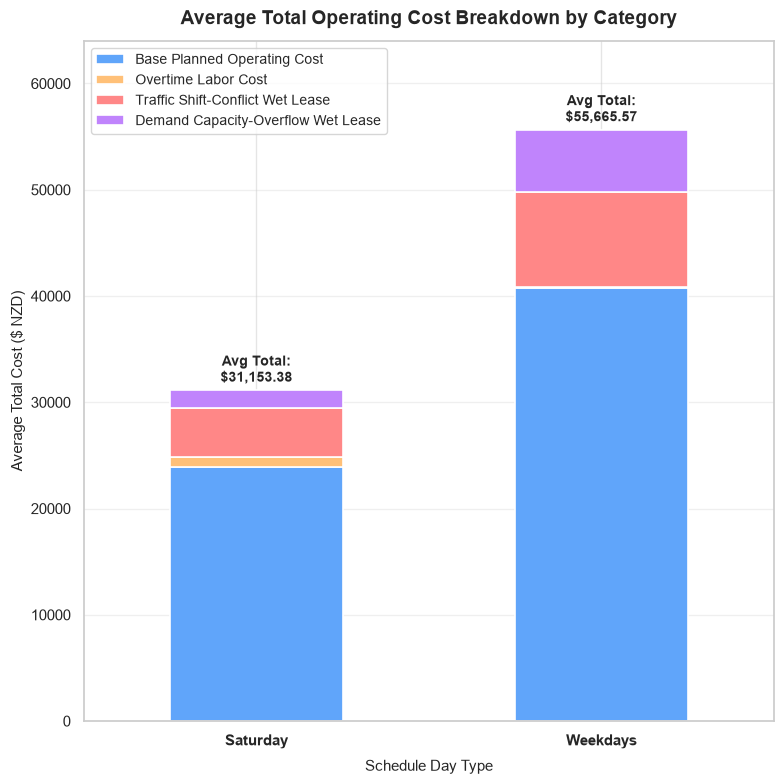

In [62]:
# ==============================================================================
# FIGURE 2: STANDALONE AVERAGE TOTAL COST BREAKDOWN BY CATEGORY
# ==============================================================================
# Make figure taller (8x8 aspect ratio)
plt.figure(figsize=(8, 8))

sim_results_df["Base_Cost"] = sim_results_df.apply(
    lambda r: baseline_metrics.loc[baseline_metrics["Day"] == r["Day"], "Original_Cost"].values[0],
    axis=1
)
sim_results_df["Overtime_Cost"] = np.maximum(
    0,
    sim_results_df["total_cost"] - sim_results_df["Base_Cost"] - sim_results_df["wet_lease_cost"] - sim_results_df["overflow_cost"]
)

cost_breakdown = sim_results_df.groupby("Day").agg(
    Base_Planned_Cost=("Base_Cost", "mean"),
    Overtime_Labor_Cost=("Overtime_Cost", "mean"),
    Traffic_Wet_Lease=("wet_lease_cost", "mean"),
    Demand_Overflow_Wet_Lease=("overflow_cost", "mean")
).reset_index()

# Lighter pastel hex palette matching your reference image
category_colors = ["#60A5FA", "#FFC078", "#FF8787", "#C084FC"]

ax2 = cost_breakdown.set_index("Day").plot(
    kind="bar",
    stacked=True,
    figsize=(8, 8),
    color=category_colors,
    edgecolor="white",
    linewidth=1.2
)

plt.title("Average Total Operating Cost Breakdown by Category", fontsize=14, fontweight="bold", pad=12)
plt.xlabel("Schedule Day Type", fontsize=11, labelpad=8)
plt.ylabel("Average Total Cost ($ NZD)", fontsize=11)
plt.xticks(rotation=0, fontsize=11, fontweight="bold")
plt.grid(axis="y", linestyle="-", alpha=0.3)

# Expand top Y-limit slightly so inside legend and top text label don't overlap bars
max_val = (cost_breakdown["Base_Planned_Cost"] +
           cost_breakdown["Overtime_Labor_Cost"] +
           cost_breakdown["Traffic_Wet_Lease"] +
           cost_breakdown["Demand_Overflow_Wet_Lease"]).max()
ax2.set_ylim(0, max_val * 1.15)

# Total cost annotations above bars
for i, row in cost_breakdown.iterrows():
    total = row["Base_Planned_Cost"] + row["Overtime_Labor_Cost"] + row["Traffic_Wet_Lease"] + row["Demand_Overflow_Wet_Lease"]
    ax2.annotate(
        f"Avg Total:\n${total:,.2f}",
        (i, total),
        textcoords="offset points",
        xytext=(0, 6),
        ha='center',
        fontweight='bold',
        fontsize=10
    )

# Place legend inside top-left of the plot
plt.legend(
    labels=[
        "Base Planned Operating Cost",
        "Overtime Labor Cost",
        "Traffic Shift-Conflict Wet Lease",
        "Demand Capacity-Overflow Wet Lease"
    ],
    loc="upper left",
    frameon=True,
    facecolor="white",
    edgecolor="#cccccc",
    fontsize=10
)

plt.tight_layout()
plt.show()

                      PAIRED T-TEST RESULTS                              
Mean Paired Cost Difference (Delta):  $+10,253.72
Standard Deviation of Difference:      $5,721.42
t-statistic:                           80.1481
p-value:                               0.0000e+00



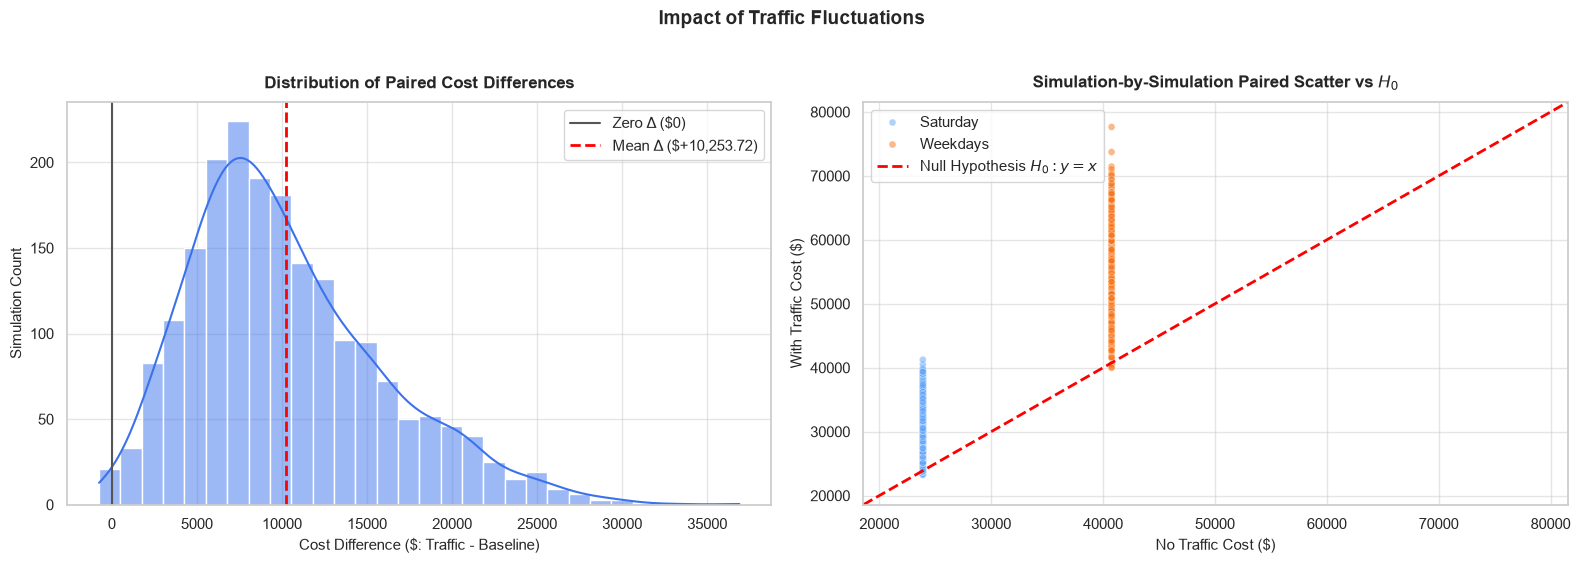

In [63]:
# ------------------------------------------------------------------------------
# 7. PAIRED T-TEST & IMPACT ANALYSIS PLOTS
# ------------------------------------------------------------------------------
from scipy import stats

# Compute paired differences per simulation run: (Simulated Cost - Baseline Cost)
sim_results_df["Baseline_Cost"] = sim_results_df.apply(
    lambda r: baseline_metrics.loc[baseline_metrics["Day"] == r["Day"], "Original_Cost"].values[0],
    axis=1
)
sim_results_df["Cost_Diff"] = sim_results_df["total_cost"] - sim_results_df["Baseline_Cost"]

# 1. Statistical Paired t-Test
t_stat, p_val = stats.ttest_rel(sim_results_df["total_cost"], sim_results_df["Baseline_Cost"])

mean_diff = sim_results_df["Cost_Diff"].mean()
std_diff = sim_results_df["Cost_Diff"].std()

print("=========================================================================")
print("                      PAIRED T-TEST RESULTS                              ")
print("=========================================================================")
print(f"Mean Paired Cost Difference (Delta):  ${mean_diff:+,.2f}")
print(f"Standard Deviation of Difference:      ${std_diff:,.2f}")
print(f"t-statistic:                           {t_stat:.4f}")
print(f"p-value:                               {p_val:.4e}")
print("=========================================================================\n")


# 2. Visualizations (Matching Reference Layout)
sns.set_theme(style="whitegrid")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5.5))

# --- Left Panel: Distribution of Paired Cost Differences ---
sns.histplot(
    data=sim_results_df,
    x="Cost_Diff",
    color="#3b72ec",
    kde=True,
    bins=30,
    edgecolor="white",
    alpha=0.5,
    ax=ax1
)

# Vertical line at Zero ($0 difference)
ax1.axvline(
    0,
    color="#555555",
    linestyle="-",
    linewidth=1.5,
    label="Zero Δ ($0)"
)

# Vertical line at Mean Difference
ax1.axvline(
    mean_diff,
    color="red",
    linestyle="--",
    linewidth=2.0,
    label=f"Mean Δ (${mean_diff:+,.2f})"
)

ax1.set_title("Distribution of Paired Cost Differences", fontsize=12, fontweight="bold", pad=10)
ax1.set_xlabel("Cost Difference ($: Traffic - Baseline)", fontsize=11)
ax1.set_ylabel("Simulation Count", fontsize=11)
ax1.legend(loc="upper right", frameon=True, facecolor="white", edgecolor="#cccccc")

# --- Right Panel: Simulation-by-Simulation Paired Scatter vs H0 ---
# Scatter plot comparing Baseline vs. Simulated Costs
sns.scatterplot(
    data=sim_results_df,
    x="Baseline_Cost",
    y="total_cost",
    hue="Day",
    palette={"Saturday": "#60A5FA", "Weekdays": "#F97316"},
    alpha=0.5,
    s=25,
    ax=ax2
)

# Red dashed 45-degree Null Hypothesis reference line (y = x)
min_val = min(sim_results_df["Baseline_Cost"].min(), sim_results_df["total_cost"].min()) * 0.8
max_val = max(sim_results_df["Baseline_Cost"].max(), sim_results_df["total_cost"].max()) * 1.05

ax2.plot(
    [min_val, max_val],
    [min_val, max_val],
    color="red",
    linestyle="--",
    linewidth=2.0,
    label="Null Hypothesis $H_0: y = x$"
)

ax2.set_xlim(min_val, max_val)
ax2.set_ylim(min_val, max_val)

ax2.set_title("Simulation-by-Simulation Paired Scatter vs $H_0$", fontsize=12, fontweight="bold", pad=10)
ax2.set_xlabel("No Traffic Cost ($)", fontsize=11)
ax2.set_ylabel("With Traffic Cost ($)", fontsize=11)

# Re-order legend entries to place Saturday & Weekdays first, followed by H0 line
handles, labels = ax2.get_legend_handles_labels()
ax2.legend(loc="upper left", frameon=True, facecolor="white", edgecolor="#cccccc")

plt.suptitle("Impact of Traffic Fluctuations", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

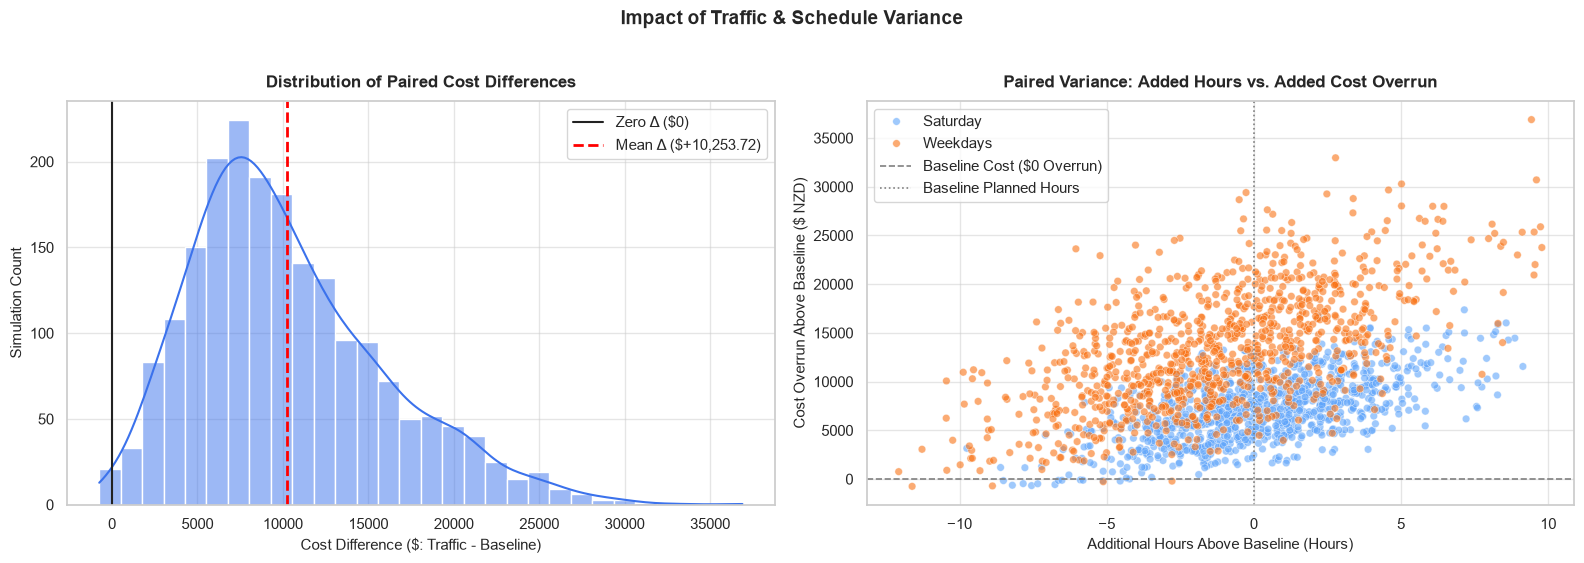

In [64]:
# ------------------------------------------------------------------------------
# 7. IMPACT OF TRAFFIC & SCHEDULE VARIANCE PLOT (UNLOGGED)
# ------------------------------------------------------------------------------
baseline_hours = routes_df.groupby("Day")["Duration_hours"].sum().to_dict()
sim_results_df["Delta_Hours"] = sim_results_df.apply(lambda r: r["total_hours"] - baseline_hours[r["Day"]], axis=1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5.5))

# Left Panel: Distribution of Paired Cost Differences
sns.histplot(
    data=sim_results_df,
    x="Cost_Diff",
    color="#3b72ec",
    kde=True,
    bins=30,
    edgecolor="white",
    alpha=0.5,
    ax=ax1
)
ax1.axvline(0, color="#222222", linestyle="-", linewidth=1.5, label="Zero Δ ($0)")
ax1.axvline(mean_diff, color="red", linestyle="--", linewidth=2.0, label=f"Mean Δ (${mean_diff:+,.2f})")
ax1.set_title("Distribution of Paired Cost Differences", fontsize=12, fontweight="bold", pad=10)
ax1.set_xlabel("Cost Difference ($: Traffic - Baseline)", fontsize=11)
ax1.set_ylabel("Simulation Count", fontsize=11)
ax1.legend(loc="upper right", frameon=True, facecolor="white", edgecolor="#cccccc")

# Right Panel: Overrun Scatter (Centered at $0 / 0 hrs)
sns.scatterplot(
    data=sim_results_df,
    x="Delta_Hours",
    y="Cost_Diff",
    hue="Day",
    palette={"Saturday": "#60A5FA", "Weekdays": "#F97316"},
    alpha=0.6,
    s=30,
    ax=ax2
)

# Reference zero lines
ax2.axhline(0, color="gray", linestyle="--", linewidth=1.2, label="Baseline Cost ($0 Overrun)")
ax2.axvline(0, color="gray", linestyle=":", linewidth=1.2, label="Baseline Planned Hours")

ax2.set_title("Paired Variance: Added Hours vs. Added Cost Overrun", fontsize=12, fontweight="bold", pad=10)
ax2.set_xlabel("Additional Hours Above Baseline (Hours)", fontsize=11)
ax2.set_ylabel("Cost Overrun Above Baseline ($ NZD)", fontsize=11)
ax2.legend(loc="upper left", frameon=True, facecolor="white", edgecolor="#cccccc")

plt.suptitle("Impact of Traffic & Schedule Variance", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

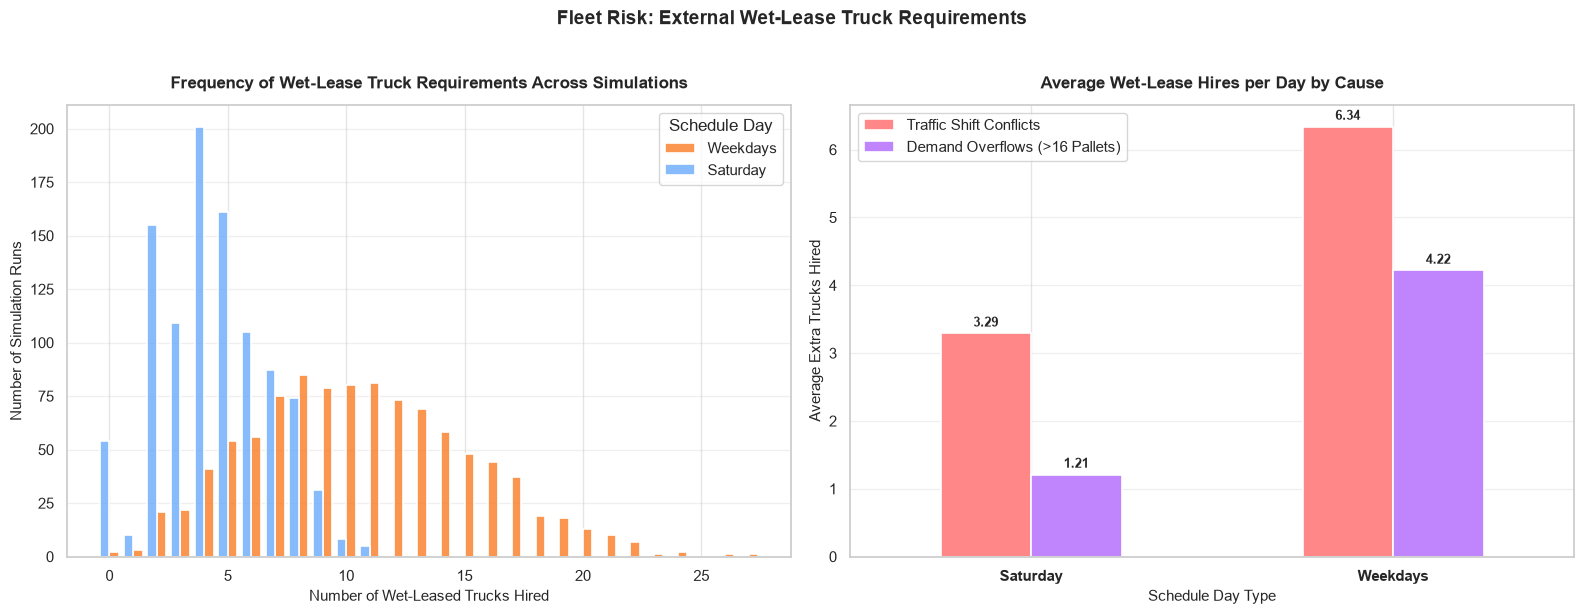

In [65]:
# ------------------------------------------------------------------------------
# 8. REFINED WET-LEASE FLEET ANALYSIS PLOTS
# ------------------------------------------------------------------------------
sim_results_df["Traffic_Wet_Leases"] = (sim_results_df["wet_lease_cost"] / WET_LEASE_COST_PER_2H_BLOCK).astype(int)
sim_results_df["Overflow_Wet_Leases"] = (sim_results_df["overflow_cost"] / WET_LEASE_COST_PER_2H_BLOCK).astype(int)
sim_results_df["Total_Wet_Leases"] = sim_results_df["Traffic_Wet_Leases"] + sim_results_df["Overflow_Wet_Leases"]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# --- Left Plot: Simulation Frequency of Required Wet-Lease Trucks ---
sns.histplot(
    data=sim_results_df,
    x="Total_Wet_Leases",
    hue="Day",
    palette={"Saturday": "#60A5FA", "Weekdays": "#F97316"},
    discrete=True,
    multiple="dodge",
    shrink=0.8,
    edgecolor="white",
    linewidth=1.2,
    ax=ax1
)

ax1.set_title("Frequency of Wet-Lease Truck Requirements Across Simulations", fontsize=12, fontweight="bold", pad=12)
ax1.set_xlabel("Number of Wet-Leased Trucks Hired", fontsize=11)
ax1.set_ylabel("Number of Simulation Runs", fontsize=11)
ax1.grid(axis="y", linestyle="-", alpha=0.3)
ax1.legend(title="Schedule Day", labels=["Weekdays", "Saturday"], loc="upper right", frameon=True, facecolor="white", edgecolor="#cccccc")

# --- Right Plot: Wet Lease Cause Breakdown (Traffic vs. Capacity) ---
cause_df = sim_results_df.groupby("Day")[["Traffic_Wet_Leases", "Overflow_Wet_Leases"]].mean().reset_index()

ax2 = cause_df.set_index("Day").plot(
    kind="bar",
    color=["#FF8787", "#C084FC"],
    edgecolor="white",
    linewidth=1.2,
    ax=ax2
)

ax2.set_title("Average Wet-Lease Hires per Day by Cause", fontsize=12, fontweight="bold", pad=12)
ax2.set_xlabel("Schedule Day Type", fontsize=11)
ax2.set_ylabel("Average Extra Trucks Hired", fontsize=11)
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=0, fontweight="bold")
ax2.grid(axis="y", linestyle="-", alpha=0.3)
ax2.legend(["Traffic Shift Conflicts", "Demand Overflows (>16 Pallets)"], loc="upper left", frameon=True, facecolor="white", edgecolor="#cccccc")

# Annotate average values on right plot
for container in ax2.containers:
    for bar in container:
        val = bar.get_height()
        if val > 0:
            ax2.annotate(
                f"{val:.2f}",
                (bar.get_x() + bar.get_width() / 2, val),
                ha='center', va='bottom',
                xytext=(0, 3), textcoords='offset points',
                fontsize=9, fontweight='bold'
            )

plt.suptitle("Fleet Risk: External Wet-Lease Truck Requirements", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()